In [1]:
import openeo

import glob
import os

import rasterio
from rasterio.mask import mask
from rasterio.merge import merge

import geopandas as gpd
import numpy as np

from scipy.ndimage import median_filter

## 1) Input setting and preparation

<Axes: >

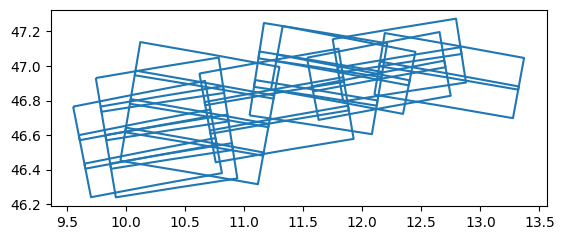

In [25]:
start_date, end_date = ["2017-07-01", "2017-09-30"]

from pathlib import Path
output_folder = Path("/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2017")
output_folder.mkdir(exist_ok=True)

bursts_filename = '/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/glacier_outline/S1_coh/s1_bursts_glacierSouthTyrol.geojson' # Extracted from the burst id map (https://sar-mpc.eu/sar-mpc-products/)
bursts = gpd.read_file(bursts_filename)
bursts.boundary.plot()

In [24]:
url = "https://openeo.dataspace.copernicus.eu"
connection = openeo.connect(url).authenticate_oidc()

Authenticated using refresh token.


In [14]:
bursts

,OGC_FID,burst_id,subswath_name,relative_orbit_number,time_from_anx_sec,orbit_pass,geometry
0,91029,30343,IW3,15,751.729080,ASCENDING,"MULTIPOLYGON Z (((9.91568 46.23872 0, 10.4392 ..."
1,91032,30344,IW3,15,754.487353,ASCENDING,"MULTIPOLYGON Z (((9.87537 46.40408 0, 10.40051..."
2,91035,30345,IW3,15,757.245626,ASCENDING,"MULTIPOLYGON Z (((9.83494 46.56942 0, 10.36171..."
3,91038,30346,IW3,15,760.003899,ASCENDING,"MULTIPOLYGON Z (((9.7944 46.73476 0, 10.32282 ..."
4,277912,92638,IW1,44,763.860783,ASCENDING,"MULTIPOLYGON Z (((11.63202 46.68756 0, 12.211 ..."
5,277915,92639,IW1,44,766.619055,ASCENDING,"MULTIPOLYGON Z (((11.58414 46.85275 0, 12.1649..."
6,608099,202700,IW2,95,2192.587465,DESCENDING,"MULTIPOLYGON Z (((13.36935 47.0467 0, 12.76395..."
7,608100,202700,IW3,95,2193.665502,DESCENDING,"MULTIPOLYGON Z (((12.21157 47.13087 0, 11.6804..."
8,608102,202701,IW2,95,2195.345739,DESCENDING,"MULTIPOLYGON Z (((13.32487 46.88142 0, 12.7213..."
9,608103,202701,IW3,95,2196.423776,DESCENDING,"MULTIPOLYGON Z (((12.17076 46.96556 0, 11.6413..."


In [42]:
bursts = bursts.iloc[[5, 6,11,12, 14,15]]
bursts  

,OGC_FID,burst_id,subswath_name,relative_orbit_number,time_from_anx_sec,orbit_pass,geometry
5,277915,92639,IW1,44,766.619055,ASCENDING,"MULTIPOLYGON Z (((11.58414 46.85275 0, 12.1649..."
6,608099,202700,IW2,95,2192.587465,DESCENDING,"MULTIPOLYGON Z (((13.36935 47.0467 0, 12.76395..."
11,748300,249434,IW1,117,756.311842,ASCENDING,"MULTIPOLYGON Z (((9.70586 46.23954 0, 10.2799 ..."
12,748301,249434,IW2,117,757.144045,ASCENDING,"MULTIPOLYGON Z (((10.76062 46.4419 0, 11.36034..."
14,748304,249435,IW2,117,759.902318,ASCENDING,"MULTIPOLYGON Z (((10.71654 46.60721 0, 11.3181..."
15,748305,249435,IW3,117,760.980355,ASCENDING,"MULTIPOLYGON Z (((11.83916 46.79507 0, 12.3682..."


## 2) Multi-temporal mosaic of coherence

For each burst compute the InSAR coherence time series and then the multitemporal max

In [26]:
import time

job_list = []

for idx, b in bursts.iterrows():import time

job_list = []

for idx, b in bursts.iterrows():

    datacube = connection.datacube_from_process(
        "sentinel1_sar_coherence",
        namespace="https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/sentinel1_sar_coherence/openeo_udp/sentinel1_sar_coherence.json",
        temporal_extent=[start_date, end_date],
        temporal_baseline=12,
        burst_id=int(b["burst_id"]),
        sub_swath=b["subswath_name"],
        coherence_window_az=7,
        coherence_window_rg=22,
        polarization="VV",
    )

    datacube = (
        datacube
        .reduce_dimension(dimension="t", reducer="max")
        .save_result(format="GTiff")
    )

    job = datacube.create_job(
        title=f"sar_coherence_T{b['relative_orbit_number']}_{b['subswath_name']}_{b['burst_id']}"
    )

    job.start()
    job_list.append(job)

    print(f"Started {job.job_id}")

    time.sleep(5)   

Started j-2609041454104aa6a6ac9a64536f7ce8
Started j-26090414542343fbab9cca2a0a9fa0b8
Started j-26090414543443ca8d34e0fc581a2157
Started j-260904145445486e8c591379e4ee79cf
Started j-26090414545644a5b01d3359113deecf
Started j-2609041455084e4ca78b3b1206622a99
Started j-2609041455194001bf19829ac63f4a39
Started j-2609041455314fa4ba078f8ba92fc3d7
Started j-2609041455424fbd8beb3e4fe97c4ec8
Started j-2609041455544338af0d231b39380307
Started j-26090414560540398090da56d48b14b4
Started j-2609041456174f0583acb88f468a36ff
Started j-26090414562944ff8d837d056d52a9ec
Started j-2609041456424efda05a800295157d94
Started j-26090414565441f6aae3f4d01e769d75
Started j-26090414570549e0b8246e064f9f0ced
Started j-260904145718431591ff0c03223bb87b
Started j-260904145730402b9dd5cfcb8cdea81d
Started j-2609041457424bd5954318060539b048
Started j-26090414575449d891aa4651e758a407
Started j-26090414580649b69ccaadffe19c22c5
Started j-2609041458174f8fa91aed1068d3ae6d
Started j-2609041458294115804f3a7f5ad2d382
Started j-2

In [53]:
connection.list_jobs()

[{'created': '2026-09-03T07:04:34Z',
  'id': 'j-2609030704344d25aa651a1bc27d992e',
  'progress': 0,
  'status': 'queued',
  'title': 'sar_coherence_T117_IW3_249435',
  'updated': '2026-09-03T08:20:36Z'},
 {'created': '2026-09-03T07:04:22Z',
  'id': 'j-2609030704224b12a2b6f62f73c08aa8',
  'progress': 0,
  'status': 'queued',
  'title': 'sar_coherence_T117_IW2_249435',
  'updated': '2026-09-03T08:20:39Z'},
 {'created': '2026-09-03T07:04:12Z',
  'id': 'j-2609030704124d67873cdc726a89a9e8',
  'progress': 0,
  'status': 'queued',
  'title': 'sar_coherence_T117_IW2_249434',
  'updated': '2026-09-03T08:20:40Z'},
 {'created': '2026-09-03T07:04:03Z',
  'id': 'j-2609030704034220b624cd629ab51153',
  'progress': 0,
  'status': 'queued',
  'title': 'sar_coherence_T117_IW1_249434',
  'updated': '2026-09-03T08:20:40Z'},
 {'created': '2026-09-03T07:03:52Z',
  'id': 'j-2609030703524484917cd694a12d9dbe',
  'status': 'running',
  'title': 'sar_coherence_T95_IW2_202700',
  'updated': '2026-09-03T08:20:41Z'},
 {'created': '2026-09-03T07:03:41Z',
  'id': 'j-2609030703414d468e780b959ff7c025',
  'status': 'running',
  'title': 'sar_coherence_T44_IW1_92639',
  'updated': '2026-09-03T08:20:42Z'},
 {'created': '2026-09-02T14:42:01Z',
  'id': 'j-2609021442014f06bf46905ef698d821',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359502',
  'updated': '2026-09-02T20:15:17Z'},
 {'created': '2026-09-02T14:41:52Z',
  'id': 'j-260902144152421aabba39faf85e4d31',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359501',
  'updated': '2026-09-02T20:08:20Z'},
 {'created': '2026-09-02T14:41:42Z',
  'id': 'j-2609021441424f2c83aa422ee0f83e80',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359500',
  'updated': '2026-09-02T20:00:20Z'},
 {'created': '2026-09-02T14:41:32Z',
  'id': 'j-260902144132408ca5a8636e311ddcde',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW2_359499',
  'updated': '2026-09-02T19:53:20Z'},
 {'created': '2026-09-02T14:41:23Z',
  'id': 'j-2609021441234d95bf932ec40181fa3f',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW1_359499',
  'updated': '2026-09-02T19:45:18Z'},
 {'created': '2026-09-02T14:41:12Z',
  'id': 'j-2609021441124116b0ba3fdeddce0763',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T168_IW1_359498',
  'updated': '2026-09-02T19:39:19Z'},
 {'created': '2026-09-02T14:41:03Z',
  'id': 'j-2609021441034897b363a1f53fca4ce1',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW3_249436',
  'updated': '2026-09-02T19:30:18Z'},
 {'created': '2026-09-02T14:40:53Z',
  'id': 'j-2609021440534c41bdca665cc3d5acb1',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW2_249436',
  'updated': '2026-09-02T19:24:19Z'},
 {'created': '2026-09-02T14:40:44Z',
  'id': 'j-26090214404445369e1b416fa24e0991',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW1_249436',
  'updated': '2026-09-02T19:16:18Z'},
 {'created': '2026-09-02T14:40:35Z',
  'id': 'j-2609021440354fa2ba158f33478b62f1',
  'status': 'error',
  'title': 'sar_coherence_T117_IW3_249435',
  'updated': '2026-09-02T19:00:41Z'},
 {'created': '2026-09-02T14:40:25Z',
  'id': 'j-2609021440254397ab72f105466cb022',
  'status': 'error',
  'title': 'sar_coherence_T117_IW2_249435',
  'updated': '2026-09-02T18:48:05Z'},
 {'created': '2026-09-02T14:40:15Z',
  'id': 'j-26090214401543b9973efab25bb97df2',
  'progress': 100,
  'status': 'finished',
  'title': 'sar_coherence_T117_IW1_249435',
  'updated': '2026-09-02T19:05:06Z'},
 {'created': '2026-09-02T14:40:06Z',
  'id': 'j-2609021440064c2e80875444d597c81d',
  'status': 'error',
  'title': 'sar_coherence_T117_IW2_249434',
  'updated': '2026-09-02T18:24:23Z'},
 {'created': '2026-09-02T14:39:56Z',
  'id': 'j-26090214395647bfac98db77ade41ef7',
  'status': 'error',
  'title': 'sar_coherence_T117_IW1_249434',
  'updated': '2026-09-02T

## 3) Download the results

If in the same session where the jobs were launched, the results can be downloaded directly with:

In [ ]:
from datetime import datetime
job_create_date = datetime.strptime('2026-08-18T11:00:00Z', "%Y-%m-%dT%H:%M:%SZ")
job_list = [connection.job(j['id']) for j in connection.list_jobs() if datetime.strptime(j['created'], "%Y-%m-%dT%H:%M:%SZ") > job_create_date]
#job_list = job_list[1:]
job_list

In [ ]:
for i, j in enumerate(job_list):

    print(i, j.describe()["title"], j.status())

    if j.status() == "finished":

        title = j.describe()["title"]
        filepath = os.path.join(output_folder, f"{title}.tiff")

        print(f"Downloading: {filepath}")

        j.get_results().download_file(filepath)

        print("Done!")

Otherwise, if in a new session, the jobs need to be retrieved using some filters (see example below for a filter on the creation date):

```python
from datetime import datetime
job_create_date = datetime.strptime('2026-03-03T14:39:00Z', "%Y-%m-%dT%H:%M:%SZ")
job_list = [connection.job(j['id']) for j in connection.list_jobs() if datetime.strptime(j['created'], "%Y-%m-%dT%H:%M:%SZ") > job_create_date]
```

## 4) Classify the glaciers

Reproject all to UTM32N with `gdalwarp`

In [12]:
coh_max_filenames = []
for f in glob.glob(os.path.join(output_folder, 'sar_coherence_T*_*EPSG32632.tiff')):
    with rasterio.open(f) as src:
        #if src.crs.to_epsg() != 32632:
        #    target_filename = f[:-4] + '_EPSG32632.tif'
        #    cmd = f'gdalwarp -t_srs EPSG:32632 -r bilinear -tr 10 10 {f} {target_filename}'
        #    os.system(cmd)
        #    coh_max_filenames.append(target_filename)
        #else:
            coh_max_filenames.append(f)
    print(f"{f}")

/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T168_IW1_359499_EPSG32632.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T95_IW3_202700_EPSG32632.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T168_IW2_359502_EPSG32632.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T95_IW3_202702_EPSG32632.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T44_IW1_92638_EPSG32632.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T117_IW1_249436_EPSG32632.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T117_IW2_249436_EPSG32632.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T117_IW1_249434_EPSG32632.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines

## 4.1) If the previous step was already done, load all files and composite files from one swadth

In [11]:
# Find all coherence files for each swadth
files = list(output_folder.glob("sar_coherence_T*_*EPSG32632.tiff"))

# Extract the track number from the filename
from collections import defaultdict

groups = defaultdict(list)

for f in files:
    parts = f.stem.split("_")
    
    track = parts[2]  
    
    groups[track].append(f)

# Create one composite for each track
for track, filenames in groups.items():

    print(f"{track}: {len(filenames)} files")

    datasets = [rasterio.open(f) for f in filenames]

    mosaic, transform = merge(
        datasets,
        method="first",
        nodata=0
    )

    profile = datasets[0].profile.copy()
    profile.update(
        height=mosaic.shape[1],
        width=mosaic.shape[2],
        transform=transform,
        count=1,
        nodata=0,
        dtype=mosaic.dtype
    )

    output_file = output_folder / f"sar_coherence_{track}_composite.tiff"

    with rasterio.open(output_file, "w", **profile) as dst:
        dst.write(mosaic[0], 1)

    for src in datasets:
        src.close()

    print(f"{output_file}")

T168: 6 files
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T168_composite.tiff
T95: 4 files
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T95_composite.tiff
T117: 5 files
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T117_composite.tiff
T15: 4 files
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T15_composite.tiff
T44: 1 files
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T44_composite.tiff


### 4.2) Create Mosaic from all of them together

In [62]:
datasets = [rasterio.open(f) for f in coh_max_filenames]

print("Found files:", datasets)

mosaic, transform = merge(datasets, method='max', nodata=np.nan)

meta = datasets[0].meta.copy()
meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": transform
})

coh_max_mosaic_filename = os.path.join(output_folder, "coh_max_mosaic.tiff")
with rasterio.open(coh_max_mosaic_filename, "w", **meta) as dst:
    dst.write(mosaic)


Found files: [<open DatasetReader name='/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2023/sar_coherence_T117_IW2_249434_EPSG32632.tiff' mode='r'>, <open DatasetReader name='/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2023/sar_coherence_T117_IW2_249435_EPSG32632.tiff' mode='r'>, <open DatasetReader name='/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2023/sar_coherence_T168_IW1_359499_EPSG32632.tiff' mode='r'>, <open DatasetReader name='/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2023/sar_coherence_T95_IW3_202700_EPSG32632.tiff' mode='r'>, <open DatasetReader name='/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2023/sar_coherence_T95_IW2_202700_EPSG32632.tiff' mode='r'>, <open DatasetReader name='/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2023/sar_coherence_T95_IW3_202702_EPSG32632.tiff' mode='r'>, <open DatasetReader name='/mnt/CEPH_PROJECTS/pr

### 5) Mask the outlines using the glacier inventory from 1997 and apply threshold

### 5.1) Max Mosaic

In [30]:
# mask the binary rasters with the glacier outlines shapefile
mask_filename = "/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/glacier_outline/glacier_inventory/SGIhom_1997_v2025.shp"

# Read glacier mask
glacier_mask = gpd.read_file(mask_filename)

max_coherence_mosaic_filename = "/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2023/coh_max_mosaic.tiff"

with rasterio.open(max_coherence_mosaic_filename) as src:

    glacier_mask_reprojected = glacier_mask.to_crs(src.crs)

    coh_th = (src.read(1) < 0.3).astype("uint8")

    threshold_profile = src.profile.copy()
    threshold_profile.update(dtype="uint8", count=1, nodata=0)

    with MemoryFile() as memfile:
        with memfile.open(**threshold_profile) as tmp_dst:
            tmp_dst.write(coh_th, 1)

        with memfile.open() as tmp_src:
            coh_th_masked, coh_th_masked_transform = mask(
                tmp_src,
                shapes=glacier_mask,
                crop=True,
                filled=True,
            )

    coh_th_masked = coh_th_masked[0]
    coh_th_meta = src.profile.copy()
    coh_th_meta.update({
        "height": coh_th_masked.shape[0],
        "width": coh_th_masked.shape[1],
        "transform": coh_th_masked_transform,
        "count": 1,
        "dtype": "uint8",
        "nodata": 0,
    })


    output_file = output_folder / "coh_max_mosaic_thresh_0.3_masked.tiff"

    # Save
    with rasterio.open(output_file, "w", **coh_th_meta) as dst:
        dst.write(coh_th_masked,1 )

    print("Saved files:", output_file)


/tmp/ipykernel_598106/1741469819.py:14: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  coh_th = (src.read(1) < 0.3).astype("uint8")


Saved files: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2023/coh_max_mosaic_thresh_0.3_masked.tiff


### 5.2.1) Max mosaic per swadth composite

In [16]:
# Find all max coherence composites for each swadth
files = list(output_folder.glob("sar_coherence_T*_composite.tiff"))
mask_filename = "/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/glacier_outline/glacier_inventory/SGIhom_1997_v2025.shp"
glacier_inventory = gpd.read_file(mask_filename)

from rasterio.io import MemoryFile

for f in files:
    print(f"  {f}")

    with rasterio.open(f) as src:
        glacier_shapes = glacier_inventory.to_crs(src.crs).geometry.values
        coh_th = (src.read(1) < 0.3).astype("uint8")

        threshold_profile = src.profile.copy()
        threshold_profile.update(dtype="uint8", count=1, nodata=0)

        with MemoryFile() as memfile:
            with memfile.open(**threshold_profile) as tmp_dst:
                tmp_dst.write(coh_th, 1)

            with memfile.open() as tmp_src:
                coh_th_masked, coh_th_masked_transform = mask(
                    tmp_src,
                    shapes=glacier_shapes,
                    crop=True,
                    filled=True,
                )

        # apply mean 3x3 filter to smooth the binary mask
        coh_th_masked = median_filter(coh_th_masked, size=3)

        coh_th_masked = coh_th_masked[0]
        coh_th_meta = src.profile.copy()
        coh_th_meta.update({
            "height": coh_th_masked.shape[0],
            "width": coh_th_masked.shape[1],
            "transform": coh_th_masked_transform,
            "count": 1,
            "dtype": "uint8",
            "nodata": 0,
        })

    output_file = output_folder / f"{f.stem}_thresh_0.3_masked.tiff"
    with rasterio.open(output_file, "w", **coh_th_meta) as dst:
        dst.write(coh_th_masked, 1)

    print(f"{output_file}")

  /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T15_composite.tiff


/tmp/ipykernel_1632199/192306614.py:13: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  coh_th = (src.read(1) < 0.3).astype("uint8")


/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T15_composite_thresh_0.3_masked.tiff
  /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T117_composite.tiff


/tmp/ipykernel_1632199/192306614.py:13: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  coh_th = (src.read(1) < 0.3).astype("uint8")


/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T117_composite_thresh_0.3_masked.tiff
  /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T95_composite.tiff


...

/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T95_composite_thresh_0.3_masked.tiff
  /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T44_composite.tiff


/tmp/ipykernel_1632199/192306614.py:13: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  coh_th = (src.read(1) < 0.3).astype("uint8")


/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T44_composite_thresh_0.3_masked.tiff
  /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T168_composite.tiff


/tmp/ipykernel_1632199/192306614.py:13: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  coh_th = (src.read(1) < 0.3).astype("uint8")


/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T168_composite_thresh_0.3_masked.tiff


### 5.2.2) Composite glacier masks from different swadth

In [17]:
mosaic_filenames = list()

# change pattern accordingly, e.g. year 2023, 2016 etc.
for f in glob.glob(os.path.join(output_folder, 'sar_coherence_T*_composite_thresh_0.3_masked.tiff')):
    with rasterio.open(f) as src:
        mosaic_filenames.append(f)
        print(f"File: {f}, CRS: {src.crs}, Bounds: {src.bounds}, Width: {src.width}, Height: {src.height}")

# Merge
mosaic, out_transform = merge(mosaic_filenames, method='first')

# Copy metadata from one source and update dimensions/transform
with rasterio.open(mosaic_filenames[0]) as ref:
    out_meta = ref.meta.copy()

out_meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform
})

with rasterio.open(output_folder / "sar_coherence_composite_swadth_thresh_0.3_first.tiff", "w", **out_meta) as dest:
    dest.write(mosaic)


File: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T168_composite_thresh_0.3_masked.tiff, CRS: EPSG:32632, Bounds: BoundingBox(left=608290.0, bottom=5144700.0, right=746060.0, top=5218920.0), Width: 13777, Height: 7422
File: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T117_composite_thresh_0.3_masked.tiff, CRS: EPSG:32632, Bounds: BoundingBox(left=608290.0, bottom=5144695.697540411, right=746060.0, top=5218915.697540411), Width: 13777, Height: 7422
File: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T95_composite_thresh_0.3_masked.tiff, CRS: EPSG:32632, Bounds: BoundingBox(left=650400.0, bottom=5160550.0, right=746060.0, top=5218920.0), Width: 9566, Height: 5837
File: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T15_composite_thresh_0.3_masked.tiff, CRS: EPSG:32632, Bounds: BoundingBox(left=608290.0, bottom=5144700.0

### 5.2.3) Create a composite of all swadth thresholded 

Combine only when all of them say it's glacier

In [51]:
mosaic_filenames = sorted(
    glob.glob(
        os.path.join(
            output_folder,
            "sar_coherence_T*_composite_thresh_0.3_masked.tiff"
        )
    )
)

datasets = [rasterio.open(f) for f in mosaic_filenames]

mosaic, out_transform = merge(
    datasets,
    method="max"
)

# Metadata
out_meta = datasets[0].meta.copy()

out_meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform,
    "count": 1,
    "dtype": "uint8",
    "nodata": 0
})

combined_filename = output_folder / "sar_coherence_composite_all_swaths_thresh_0.3_masked.tiff"

with rasterio.open(combined_filename, "w", **out_meta) as dst:
    dst.write(mosaic[0], 1)

# Close files
for ds in datasets:
    ds.close()

print(f"Saved merged composite: {combined_filename}")

Saved merged composite: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2023/sar_coherence_composite_all_swaths_thresh_0.3_masked.tiff


### 5.3) Create mosaic from descending and ascending swadth

In [18]:
import re

files = list(output_folder.glob("sar_coherence_T*_composite.tiff"))

ascending_orbits = [15, 44, 117]
descending_orbits = [95, 168]

# Separate files
ascending_files = []
descending_files = []

for f in files:

    # Extract T number from filename
    match = re.search(r"T(\d+)", f.name)

    if match:
        orbit = int(match.group(1))

        if orbit in ascending_orbits:
            ascending_files.append(f)

        elif orbit in descending_orbits:
            descending_files.append(f)

print("Ascending:")
for f in ascending_files:
    print(f)

print("\nDescending:")
for f in descending_files:
    print(f)

Ascending:
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T15_composite.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T117_composite.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T44_composite.tiff

Descending:
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T95_composite.tiff
/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/sar_coherence_T168_composite.tiff


In [19]:
def merge_swaths(files, output_filename):

    datasets = [rasterio.open(f) for f in files]

    mosaic, transform = merge(
        datasets,
        method="max",
        nodata=0
    )

    meta = datasets[0].meta.copy()

    meta.update({
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": transform,
        "count": 1,
        "nodata": 0
    })

    with rasterio.open(output_filename, "w", **meta) as dst:
        dst.write(mosaic)

    for ds in datasets:
        ds.close()

    print(f"Saved: {output_filename}")

In [20]:
ascending_filename = output_folder / "coh_mosaic_ascending.tiff"
descending_filename = output_folder / "coh_mosaic_descending.tiff"

merge_swaths(
    ascending_files,
    ascending_filename
)

merge_swaths(
    descending_files,
    descending_filename
)

Saved: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/coh_mosaic_ascending.tiff
Saved: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/coh_mosaic_descending.tiff


In [21]:
ascending_filename = output_folder / "coh_mosaic_ascending.tiff"
descending_filename = output_folder / "coh_mosaic_descending.tiff"

mask_filename = "/mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/glacier_outline/glacier_inventory/SGIhom_1997_v2025.shp"
glacier_inventory = gpd.read_file(mask_filename)


def threshold_and_clip(input_filename, output_filename):
    with rasterio.open(input_filename) as src:
        glacier_shapes = glacier_inventory.to_crs(src.crs).geometry.values

        clipped, clipped_transform = mask(
            src,
            shapes=glacier_shapes,
            crop=True,
            filled=False,
        )
        glacier = ((clipped[0] < 0.5) & ~clipped[0].mask).astype("uint8")

        output_meta = src.meta.copy()
        output_meta.update(
            {
                "height": glacier.shape[0],
                "width": glacier.shape[1],
                "transform": clipped_transform,
                "count": 1,
                "dtype": "uint8",
                "nodata": 0,
            }
        )

    with rasterio.open(output_filename, "w", **output_meta) as dst:
        dst.write(glacier, 1)

    print(f"Saved: {output_filename}")


threshold_and_clip(ascending_filename, output_folder / "masked_ascending_0.5.tif")
threshold_and_clip(descending_filename, output_folder / "masked_descending_0.5.tif")

Saved: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/masked_ascending_0.5.tif
Saved: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/masked_descending_0.5.tif


In [22]:
import skimage as ski

morphology_structure = ski.morphology.disk(3)


def apply_morphological_filter(input_filename, output_filename):
    with rasterio.open(input_filename) as src:
        binary_mask = src.read(1).astype(bool)
        filtered_mask = ski.morphology.opening(binary_mask, morphology_structure)
        filtered_mask = ski.morphology.closing(filtered_mask, morphology_structure)

        output_meta = src.meta.copy()
        output_meta.update(
            {
                "count": 1,
                "dtype": "uint8",
                "nodata": 0,
            }
        )

    with rasterio.open(output_filename, "w", **output_meta) as dst:
        dst.write(filtered_mask.astype("uint8"), 1)

    print(f"Saved: {output_filename}")


apply_morphological_filter(
    output_folder / "masked_ascending_0.5.tif",
    output_folder / "masked_ascending_0.5_morphFilter_3.tif",
)
apply_morphological_filter(
    output_folder / "masked_descending_0.5.tif",
    output_folder / "masked_descending_0.5_morphFilter_3.tif",
)

/tmp/ipykernel_1632199/2658778210.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  binary_mask = src.read(1).astype(bool)


Saved: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/masked_ascending_0.5_morphFilter_3.tif
Saved: /mnt/CEPH_PROJECTS/provinzBZ_risk_EO/GlacierOutlines/tests/coherence/2016/masked_descending_0.5_morphFilter_3.tif
